# Benchmarking the Rust Numerical Computing Examples Against NumPy and scikit-learn

This notebook compares the Rust implementations in this repository with widely used Python scientific-computing libraries. 

The Rust code is exposed to Python through `pyo3` bindings and installed with `maturin`.

## What We're Testing

The goal is straightforward: comapre the Rust implementations in this repository and pit them directly against the Python numerical libraries they conceptually mirror — NumPy and scikit-learn.

- `stats::mean` vs `numpy.mean`
- `stats::percentile` vs `numpy.percentile`
- `linalg::matmul` vs `numpy.matmul`
- `linalg::inv` vs `numpy.linalg.inv`
- `LinearRegression::fit`, `predict`, and `score` vs `sklearn.linear_model.LinearRegression`

These functions are implemented across three files — `src/stats.rs`, `src/linalg.rs`, and 
`src/linear_regression.rs` — and represent readable implementations of the underlying math without leaning on any external Rust libraries.

The honest framing here is that this is a comparison of **from-scratch Rust** against 
**production-grade Python** — libraries that have had decades of optimization work and sit 
on top of heavily tuned native backends like BLAS and LAPACK.

In [1]:
from __future__ import annotations

import gc
import os
import statistics
from pathlib import Path
from time import perf_counter_ns

NOTEBOOK_DIR = Path.cwd()
MPLCONFIGDIR = NOTEBOOK_DIR / '.mplconfig'
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPLCONFIGDIR))

import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression as SklearnLinearRegression

import rust_numeric as rn

## Benchmark Methodology

The methodology is kept intentionally simple:

1. All inputs are generated once upfront with a fixed random seed — no variability between runs.
2. Each function is warmed up before timing starts to avoid cold-start noise.
3. Every benchmark runs multiple times and reports the **median runtime** to smooth out outliers.
4. Python lists are prepared ahead of the timed section so the clock measures the Rust call 
itself, not the overhead of repeated list conversion.

That last point is worth calling out. NumPy and scikit-learn are array-native — they live and 
breathe contiguous memory. Our Rust bindings currently accept Python sequences, which means 
every call crosses a conversion boundary. The results reflect **real-world notebook usage** 
through that binding layer, not an idealized low-level FFI microbenchmark. 

In [2]:
def benchmark(label, func, *, repeats=9, warmup=2):
    for _ in range(warmup):
        func()

    timings_ms = []
    gc_was_enabled = gc.isenabled()
    gc.disable()
    try:
        for _ in range(repeats):
            start = perf_counter_ns()
            func()
            end = perf_counter_ns()
            timings_ms.append((end - start) / 1_000_000)
    finally:
        if gc_was_enabled:
            gc.enable()

    return {
        'label': label,
        'median_ms': statistics.median(timings_ms),
        'mean_ms': statistics.mean(timings_ms),
        'min_ms': min(timings_ms),
        'max_ms': max(timings_ms),
        'all_ms': timings_ms,
    }


def summarize_pair(operation, rust_result, python_result):
    speed_ratio = python_result['median_ms'] / rust_result['median_ms']
    faster = 'Rust' if speed_ratio > 1 else 'Python'
    factor = speed_ratio if speed_ratio > 1 else 1 / speed_ratio
    return {
        'operation': operation,
        'rust_median_ms': rust_result['median_ms'],
        'python_median_ms': python_result['median_ms'],
        'faster': faster,
        'factor': factor,
    }


def print_summary(rows):
    header = f"{'Operation':<24} {'Rust median (ms)':>16} {'Python median (ms)':>18} {'Faster':>10} {'Factor':>10}"
    print(header)
    print('-' * len(header))
    for row in rows:
        print(
            f"{row['operation']:<24} {row['rust_median_ms']:>16.3f} {row['python_median_ms']:>18.3f} {row['faster']:>10} {row['factor']:>10.2f}"
        )

## Generate benchmark inputs

The data sizes below are large enough to reveal meaningful differences without making the notebook slow to execute in an interactive session.

In [3]:
rng = np.random.default_rng(42)

vector = rng.normal(size=250_000)
vector_list = vector.tolist()

percentile_q = 75.0

matmul_a = rng.normal(size=(200, 200))
matmul_b = rng.normal(size=(200, 200))
matmul_a_list = matmul_a.tolist()
matmul_b_list = matmul_b.tolist()

inv_matrix = rng.normal(size=(120, 120))
inv_matrix = inv_matrix + np.eye(inv_matrix.shape[0]) * 0.5
inv_matrix_list = inv_matrix.tolist()

x = rng.normal(size=(20_000, 8))
beta = np.array([1.5, -2.0, 0.75, 0.0, 3.0, -1.2, 0.4, 2.2])
noise = rng.normal(scale=0.1, size=x.shape[0])
y = x @ beta + 0.8 + noise

x_list = x.tolist()
y_list = y.tolist()

print('Vector length:', len(vector_list))
print('Matrix multiply shape:', matmul_a.shape, 'x', matmul_b.shape)
print('Inverse matrix shape:', inv_matrix.shape)
print('Regression design matrix shape:', x.shape)

Vector length: 250000
Matrix multiply shape: (200, 200) x (200, 200)
Inverse matrix shape: (120, 120)
Regression design matrix shape: (20000, 8)


In [4]:
rust_lr = rn.LinearRegression().fit(x_list, y_list)
sk_lr = SklearnLinearRegression().fit(x, y)

agreement = {
    'mean': abs(rn.mean(vector_list) - float(np.mean(vector))),
    'percentile_75': abs(rn.percentile(vector_list, percentile_q) - float(np.percentile(vector, percentile_q))),
    'matmul_max_abs_diff': float(np.max(np.abs(np.array(rn.matmul(matmul_a_list, matmul_b_list)) - (matmul_a @ matmul_b)))),
    'inverse_max_abs_diff': float(np.max(np.abs(np.array(rn.inverse(inv_matrix_list)) - np.linalg.inv(inv_matrix)))),
    'linear_regression_coef_max_abs_diff': float(np.max(np.abs(np.array(rust_lr.coef_) - sk_lr.coef_))),
    'linear_regression_intercept_abs_diff': abs(rust_lr.intercept_ - float(sk_lr.intercept_)),
}

agreement

{'mean': 1.8810907692623502e-17,
 'percentile_75': 0.0,
 'matmul_max_abs_diff': 6.394884621840902e-14,
 'inverse_max_abs_diff': 5.788258761185716e-11,
 'linear_regression_coef_max_abs_diff': 1.7319479184152442e-14,
 'linear_regression_intercept_abs_diff': 1.1102230246251565e-15}

## Run the benchmarks

Each comparison pairs a Rust function with the closest Python equivalent. For the regression model, `fit`, `predict`, and `score` are benchmarked separately because those operations have different cost profiles.

In [5]:
results = []


sum_rust = benchmark('rust sum', lambda: rn.sum(vector_list))
sum_numpy = benchmark('numpy sum', lambda: float(np.sum(vector)))
results.append(summarize_pair('sum', sum_rust, sum_numpy))

mean_rust = benchmark('rust mean', lambda: rn.mean(vector_list))
mean_numpy = benchmark('numpy mean', lambda: float(np.mean(vector)))
results.append(summarize_pair('mean', mean_rust, mean_numpy))

variance_rust = benchmark('rust variance', lambda: rn.variance(vector_list))
variance_numpy = benchmark('numpy variance', lambda: float(np.var(vector)))
results.append(summarize_pair('variance', variance_rust, variance_numpy))


percentile_rust = benchmark('rust percentile', lambda: rn.percentile(vector_list, percentile_q), repeats=7)
percentile_numpy = benchmark('numpy percentile', lambda: float(np.percentile(vector, percentile_q)), repeats=7)
results.append(summarize_pair('percentile(75)', percentile_rust, percentile_numpy))

matmul_rust = benchmark('rust matmul', lambda: rn.matmul(matmul_a_list, matmul_b_list), repeats=5)
matmul_numpy = benchmark('numpy matmul', lambda: matmul_a @ matmul_b, repeats=5)
results.append(summarize_pair('matrix multiply', matmul_rust, matmul_numpy))

inverse_rust = benchmark('rust inverse', lambda: rn.inverse(inv_matrix_list), repeats=5)
inverse_numpy = benchmark('numpy inverse', lambda: np.linalg.inv(inv_matrix), repeats=5)
results.append(summarize_pair('matrix inverse', inverse_rust, inverse_numpy))

fit_rust = benchmark(
    'rust fit',
    lambda: rn.LinearRegression().fit(x_list, y_list),
    repeats=5,
)
fit_sklearn = benchmark(
    'sklearn fit',
    lambda: SklearnLinearRegression().fit(x, y),
    repeats=5,
)
results.append(summarize_pair('linear regression fit', fit_rust, fit_sklearn))

trained_rust = rn.LinearRegression().fit(x_list, y_list)
trained_sklearn = SklearnLinearRegression().fit(x, y)

predict_rust = benchmark('rust predict', lambda: trained_rust.predict(x_list), repeats=7)
predict_sklearn = benchmark('sklearn predict', lambda: trained_sklearn.predict(x), repeats=7)
results.append(summarize_pair('linear regression predict', predict_rust, predict_sklearn))

score_rust = benchmark('rust score', lambda: trained_rust.score(x_list, y_list), repeats=7)
score_sklearn = benchmark('sklearn score', lambda: trained_sklearn.score(x, y), repeats=7)
results.append(summarize_pair('linear regression score', score_rust, score_sklearn))

print_summary(results)

Operation                Rust median (ms) Python median (ms)     Faster     Factor
----------------------------------------------------------------------------------
sum                                 1.829              0.063     Python      29.17
mean                                1.407              0.055     Python      25.40
variance                            1.590              0.299     Python       5.33
percentile(75)                      6.848              3.478     Python       1.97
matrix multiply                    29.248              0.306     Python      95.43
matrix inverse                      3.985              0.409     Python       9.75
linear regression fit              16.170              1.749     Python       9.25
linear regression predict            5.412              0.087     Python      62.30
linear regression score             2.650              0.676     Python       3.92


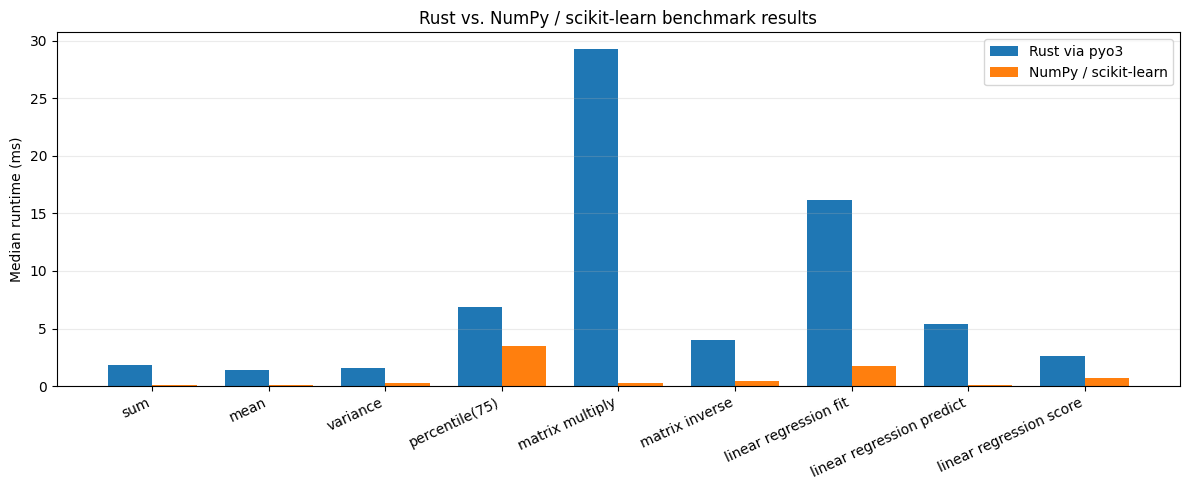

In [7]:
operations = [row['operation'] for row in results]
rust_times = [row['rust_median_ms'] for row in results]
python_times = [row['python_median_ms'] for row in results]

x_pos = np.arange(len(operations))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x_pos - width / 2, rust_times, width, label='Rust via pyo3')
ax.bar(x_pos + width / 2, python_times, width, label='NumPy / scikit-learn')
ax.set_ylabel('Median runtime (ms)')
ax.set_title('Rust vs. NumPy / scikit-learn benchmark results')
ax.set_xticks(x_pos)
ax.set_xticklabels(operations, rotation=25, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

## Benchmark Results: Rust vs Python

Python wins across the board — but that's not the full story, and it's not really a surprise.

---

### Matrix Multiply: The Biggest Gap (95x)

The most striking result is matrix multiplication — Rust takes 29ms versus NumPy's 0.31ms, 
a 95x difference. This is almost entirely explained by data layout. The Rust implementation 
uses `Vec<Vec<f64>>`, which scatters rows across the heap, while NumPy operates on a single 
contiguous block of memory and immediately hands off to **BLAS** — a hand-tuned linear algebra 
library that processes multiple values simultaneously using SIMD CPU instructions. This single 
bottleneck cascades directly into linear regression fit (9.25x slower), since fit is 
essentially matrix multiply + inverse under the hood.

---

### Scalar Operations: Sum & Mean (25–29x slower)

Sum and mean being 25–29x slower in Rust is counterintuitive for simple loops. The likely 
culprits are:
- **Conversion overhead** — Python lists must be converted to `Vec<f64>` on every call
- **Vectorization** — NumPy's sum runs SIMD code on a pre-allocated contiguous array

---

### Bright Spots

Percentile (1.97x) and linear regression score (3.92x) are the most competitive results — 
both involve logic that NumPy and scikit-learn can't fully hand off to BLAS, which narrows 
the gap considerably.

---

### The Real Takeaway

The comparison here isn't strictly Rust vs. Python; it’s baseline, handwritten Rust against decades of fine-tuned Fortran/C libraries. While the Rust implementation is intereprtable and correct, there are two primary changes still required to match the performance of those underlying C-extensions:

1. Switch from `Vec<Vec<f64>>` to flat contiguous arrays
2. Link against BLAS for matrix operations

Improving the data layout alone would likely move matrix multiplication from roughly 95x slower to competitive with, or potentially faster than, NumPy. In other words, the current performance gap appears to be driven by implementation choices rather than any fundamental limitation of Rust. Future work should focus on additional optimizations such as memory layout improvements, cache-aware algorithms, vectorization, and parallelism to better realize Rust’s performance potential.